In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import re
from matplotlib import pyplot as plt
import json
import nltk
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
import pandas as pd
data= pd.read_csv("data_tweets.csv")
data.head()

,Unnamed: 0,username,description,location,following,followers,totaltweets,retweetcount,text,hashtags
0,0,bollybubble,Bollywood Bubble - Your One Stop Destination F...,"Mumbai, Maharashtra",440,132406,51202,1,Sahil Shah identified as prime suspect in the ...,"['SushantSinghRajput', 'SahilShah', 'Bollywood..."
1,1,sushantssmile,ᴡᴀɴᴛɪɴɢ ᴛᴏ ʟɪᴠᴇ ᴀs ʏᴏᴜʀ sᴍɪʟᴇ\nᴊᴜsᴛ ᴏɴᴇ ʟᴀsᴛ ᴛ...,∞,369,412,11591,17,Somewhere' between neurons &amp; narratives......,"['SushantSinghRajput', 'sushanting', 'thebesth..."
2,2,Namita67793491,Justice for SSR,NaN,66,89,20550,5,Ppl trending National Embarrassment CBI - U R ...,[]
3,3,being_grapher04,Photographer.\nSushant Singh Rajput's Fan\nSSR...,भारत,82,27,20,0,We all are missing your need. \n#SushantSinghR...,"['SushantSinghRajput', 'JusticeForSushantSingh..."
4,4,sushantssmile,ᴡᴀɴᴛɪɴɢ ᴛᴏ ʟɪᴠᴇ ᴀs ʏᴏᴜʀ sᴍɪʟᴇ\nᴊᴜsᴛ ᴏɴᴇ ʟᴀsᴛ ᴛ...,∞,369,412,11591,1,"Hi All,\n\nPlease sign this petition.\n\n#Just...","['JusticeForSushantSinghRajput', 'SushantSingh..."


Loads data and libraries, displays head.

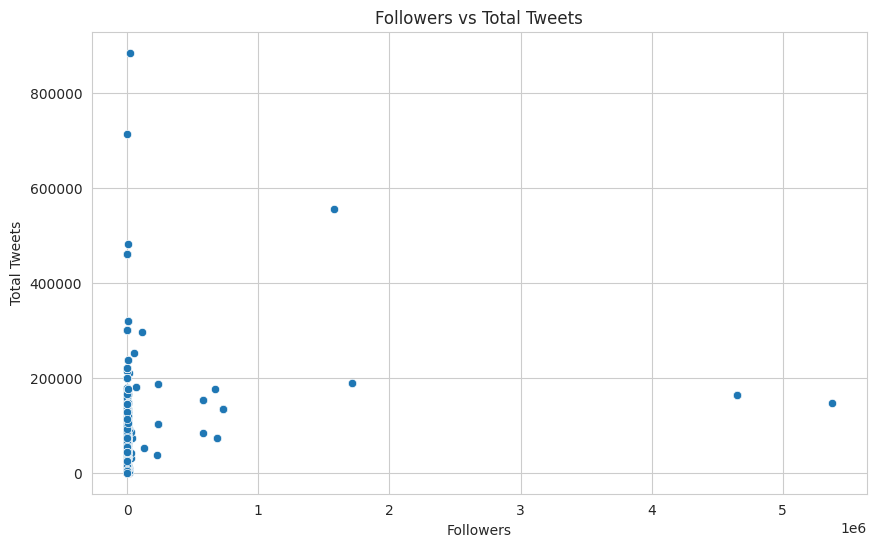

In [ ]:
# Scatter plot of followers vs totaltweets
plt.figure(figsize=(10, 6))
sns.scatterplot(x='followers', y='totaltweets', data=df)
plt.title('Followers vs Total Tweets')
plt.xlabel('Followers')
plt.ylabel('Total Tweets')
plt.show()

Seeing if more followers means more tweets.

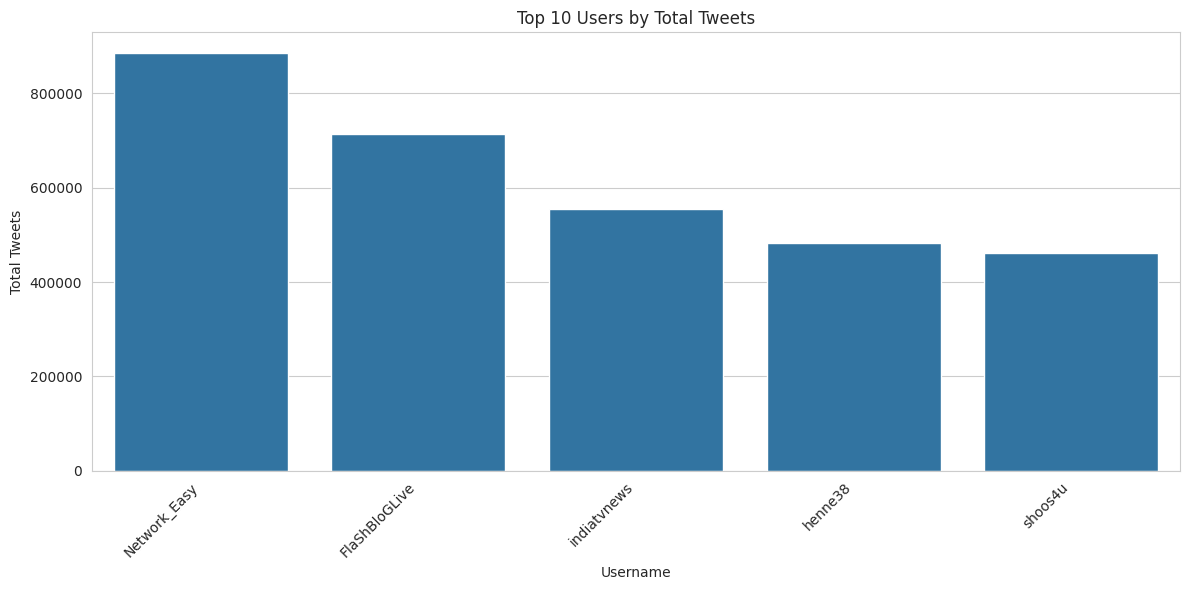

In [ ]:
# Get top 10 users by total tweets
top_users = df.nlargest(10, 'totaltweets')

# Bar plot of top 10 users by total tweets
plt.figure(figsize=(12, 6))
sns.barplot(x='username', y='totaltweets', data=top_users)
plt.title('Top 10 Users by Total Tweets')
plt.xlabel('Username')
plt.ylabel('Total Tweets')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

Checking out who tweets the most.

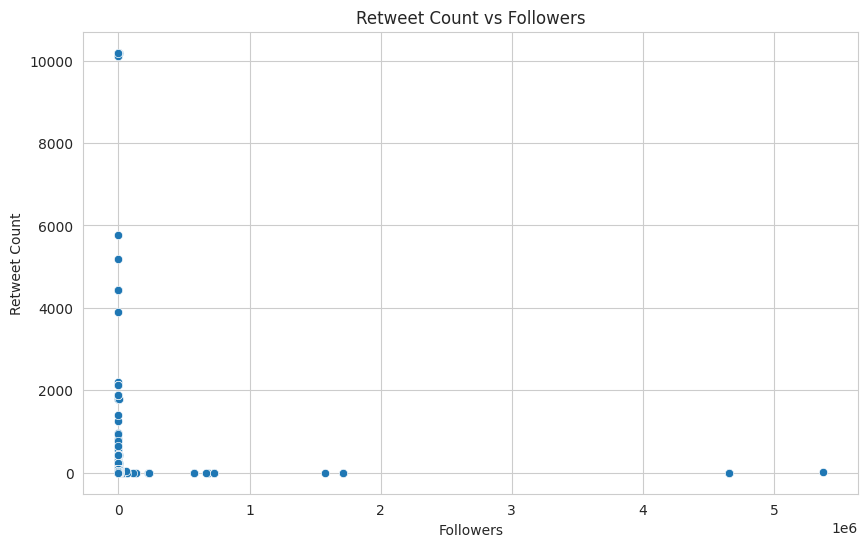

In [ ]:
# Scatter plot of retweetcount vs followers
plt.figure(figsize=(10, 6))
sns.scatterplot(x='followers', y='retweetcount', data=df)
plt.title('Retweet Count vs Followers')
plt.xlabel('Followers')
plt.ylabel('Retweet Count')
plt.show()

 scatter plot to see if there's a relationship between 'retweetcount' and 'followers'.

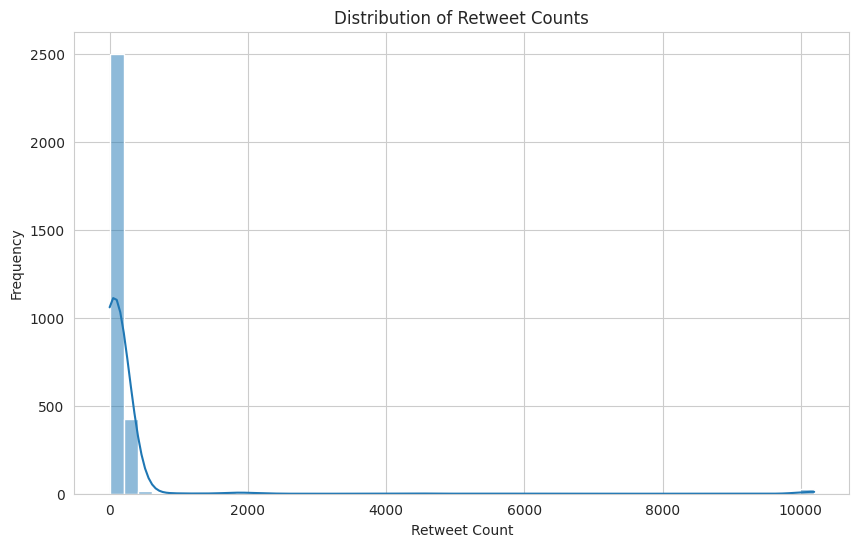

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of the 'retweetcount' column
plt.figure(figsize=(10, 6))
sns.histplot(df['retweetcount'], bins=50, kde=True)
plt.title('Distribution of Retweet Counts')
plt.xlabel('Retweet Count')
plt.ylabel('Frequency')
plt.show()

Looking at how many retweets tweets usually get.

In [ ]:
def emoji(tweet):
    # Smile -- :), : ), :-), (:, ( :, (-:, :') , :O
    tweet = re.sub(r'(:\s?\)|:-\)|\(\s?:|\(-:|:\'\)|:O)', ' positiveemoji ', tweet)
    # Laugh -- :D, : D, :-D, xD, x-D, XD, X-D
    tweet = re.sub(r'(:\s?D|:-D|x-?D|X-?D)', ' positiveemoji ', tweet)
    # Love -- <3, :*
    tweet = re.sub(r'(<3|:\*)', ' positiveemoji ', tweet)
    # Wink -- ;-), ;), ;-D, ;D, (;,  (-; , @-)
    tweet = re.sub(r'(;-?\)|;-?D|\(-?;|@-\))', ' positiveemoji ', tweet)
    # Sad -- :-(, : (, :(, ):, )-:, :-/ , :-|
    tweet = re.sub(r'(:\s?\(|:-\(|\)\s?:|\)-:|:-/|:-\|)', ' negetiveemoji ', tweet)
    # Cry -- :,(, :'(, :"(
    tweet = re.sub(r'(:,\(|:\'\(|:"\()', ' negetiveemoji ', tweet)
    return tweet

Function to replace emojis with text.

In [ ]:
with open('contractions.json', 'r') as f:
    contractions_dict = json.load(f)
contractions = contractions_dict

Loads contractions from a JSON file.

In [ ]:
import re

def process_tweet(tweet):
    tweet = tweet.lower()                                             # Lowercases the string
    tweet = re.sub(r'@[^\s]+','',tweet)                              # Removes usernames
    tweet = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))',' ',tweet)   # Remove URLs
    tweet = re.sub(r"\d+"," ", str(tweet))                           # Removes all digits
    tweet = re.sub(r'&quot;'," ", tweet)                               # Remove (&quot;)
    tweet = emoji(tweet)                                              # Replaces Emojis
    tweet = re.sub(r"\b[a-zA-Z]\b", "", str(tweet))                   # Removes all single characters
    for word in tweet.split():
        if word.lower() in contractions:
            tweet = tweet.replace(word, contractions[word.lower()])   # Replaces contractions
    tweet = re.sub(r"[^\w\s]", " ", str(tweet))                       # Removes all punctuations
    tweet = re.sub(r'(.)\1+', r'\1\1', tweet)                         # Convert more than 2 letter repetitions to 2 letter
    tweet = re.sub(r"\s+", " ", str(tweet))                           # Replaces double spaces with single space
    return tweet

Function to clean and preprocess tweets.

In [ ]:
data['processed_tweet'] = np.vectorize(process_tweet)(data['text'])
data.head()

,Unnamed: 0,username,description,location,following,followers,totaltweets,retweetcount,text,hashtags,processed_tweet
0,0,bollybubble,Bollywood Bubble - Your One Stop Destination F...,"Mumbai, Maharashtra",440,132406,51202,1,Sahil Shah identified as prime suspect in the ...,"['SushantSinghRajput', 'SahilShah', 'Bollywood...",sahil shah identified as prime suspect in the ...
1,1,sushantssmile,ᴡᴀɴᴛɪɴɢ ᴛᴏ ʟɪᴠᴇ ᴀs ʏᴏᴜʀ sᴍɪʟᴇ\nᴊᴜsᴛ ᴏɴᴇ ʟᴀsᴛ ᴛ...,∞,369,412,11591,17,Somewhere' between neurons &amp; narratives......,"['SushantSinghRajput', 'sushanting', 'thebesth...",somewhere between neurons amp narratives susha...
2,2,Namita67793491,Justice for SSR,NaN,66,89,20550,5,Ppl trending National Embarrassment CBI - U R ...,[],ppl trending national embarrassment cbi the em...
3,3,being_grapher04,Photographer.\nSushant Singh Rajput's Fan\nSSR...,भारत,82,27,20,0,We all are missing your need. \n#SushantSinghR...,"['SushantSinghRajput', 'JusticeForSushantSingh...",we all are missing your need sushantsinghrajpu...
4,4,sushantssmile,ᴡᴀɴᴛɪɴɢ ᴛᴏ ʟɪᴠᴇ ᴀs ʏᴏᴜʀ sᴍɪʟᴇ\nᴊᴜsᴛ ᴏɴᴇ ʟᴀsᴛ ᴛ...,∞,369,412,11591,1,"Hi All,\n\nPlease sign this petition.\n\n#Just...","['JusticeForSushantSinghRajput', 'SushantSingh...",hi all please sign this petition justiceforsus...


Applies preprocessing to tweets and shows head.

In [ ]:
tokenized_tweet = data['processed_tweet'].apply(lambda x: x.split())
tokenized_tweet.head()

,processed_tweet
0,"[sahil, shah, identified, as, prime, suspect, ..."
1,"[somewhere, between, neurons, amp, narratives,..."
2,"[ppl, trending, national, embarrassment, cbi, ..."
3,"[we, all, are, missing, your, need, sushantsin..."
4,"[hi, all, please, sign, this, petition, justic..."


Tokenizes processed tweets by splitting words and shows head.

In [ ]:
 import nltk
 nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Downloads the WordNet corpus for lemmatization.

In [ ]:
from nltk.stem.wordnet import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

tokenized_tweet = tokenized_tweet.apply(lambda x: [lemmatizer.lemmatize(i) for i in x])
tokenized_tweet.head()

,processed_tweet
0,"[sahil, shah, identified, a, prime, suspect, i..."
1,"[somewhere, between, neuron, amp, narrative, s..."
2,"[ppl, trending, national, embarrassment, cbi, ..."
3,"[we, all, are, missing, your, need, sushantsin..."
4,"[hi, all, please, sign, this, petition, justic..."


Lemmatizes tokens to their base form and shows head.

In [ ]:
for i in range(len(tokenized_tweet)):


     tokenized_tweet[i] = ' '.join(tokenized_tweet[i])


     #tokenized_tweet[i] = ' '.join([word for word in tokenized_tweet[i] if word not in stopwords])


data['processed_tweet'] = tokenized_tweet
data.head()

,Unnamed: 0,username,description,location,following,followers,totaltweets,retweetcount,text,hashtags,processed_tweet
0,0,bollybubble,Bollywood Bubble - Your One Stop Destination F...,"Mumbai, Maharashtra",440,132406,51202,1,Sahil Shah identified as prime suspect in the ...,"['SushantSinghRajput', 'SahilShah', 'Bollywood...",sahil shah identified a prime suspect in the d...
1,1,sushantssmile,ᴡᴀɴᴛɪɴɢ ᴛᴏ ʟɪᴠᴇ ᴀs ʏᴏᴜʀ sᴍɪʟᴇ\nᴊᴜsᴛ ᴏɴᴇ ʟᴀsᴛ ᴛ...,∞,369,412,11591,17,Somewhere' between neurons &amp; narratives......,"['SushantSinghRajput', 'sushanting', 'thebesth...",somewhere between neuron amp narrative sushant...
2,2,Namita67793491,Justice for SSR,NaN,66,89,20550,5,Ppl trending National Embarrassment CBI - U R ...,[],ppl trending national embarrassment cbi the em...
3,3,being_grapher04,Photographer.\nSushant Singh Rajput's Fan\nSSR...,भारत,82,27,20,0,We all are missing your need. \n#SushantSinghR...,"['SushantSinghRajput', 'JusticeForSushantSingh...",we all are missing your need sushantsinghrajpu...
4,4,sushantssmile,ᴡᴀɴᴛɪɴɢ ᴛᴏ ʟɪᴠᴇ ᴀs ʏᴏᴜʀ sᴍɪʟᴇ\nᴊᴜsᴛ ᴏɴᴇ ʟᴀsᴛ ᴛ...,∞,369,412,11591,1,"Hi All,\n\nPlease sign this petition.\n\n#Just...","['JusticeForSushantSinghRajput', 'SushantSingh...",hi all please sign this petition justiceforsus...


Joins tokens back into strings and updates the DataFrame.

In [ ]:
data=data[['text','processed_tweet']]
data

,text,processed_tweet
0,Sahil Shah identified as prime suspect in the ...,sahil shah identified a prime suspect in the d...
1,Somewhere' between neurons &amp; narratives......,somewhere between neuron amp narrative sushant...
2,Ppl trending National Embarrassment CBI - U R ...,ppl trending national embarrassment cbi the em...
3,We all are missing your need. \n#SushantSinghR...,we all are missing your need sushantsinghrajpu...
4,"Hi All,\n\nPlease sign this petition.\n\n#Just...",hi all please sign this petition justiceforsus...
...,...,...
2995,@ShaheenaMd1 @Srishti15802104 Rhea Chakarborty...,rhea chakarborty is an extortionist she looted...
2996,Its #NewMoon on 12th Apr. New Moon brings in n...,it newmoon on th apr new moon brings in new en...
2997,🔱 Trend Activity Today 🔱\n\n Rhea Planted In S...,trend activity today rhea planted in ssr life ...
2998,@REHANASUSHANT @ips_nupurprasad @AmitShah @DoP...,rhea chakarborty is an extortionist she looted...


Selects and displays original and processed tweet columns.

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00


Installs the vaderSentiment library for sentiment analysis.

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def print_sentiment_scores(sentence):
    snt = analyser.polarity_scores(sentence)

data['neg'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['neg'])
data['neu'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['neu'])
data['pos'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['pos'])
data['compound'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['compound'])
data[['processed_tweet','neg','pos','compound']].head()

,processed_tweet,neg,pos,compound
0,sahil shah identified a prime suspect in the d...,0.115,0.000,-0.2960
1,somewhere between neuron amp narrative sushant...,0.000,0.000,0.0000
2,ppl trending national embarrassment cbi the em...,0.225,0.073,-0.7506
3,we all are missing your need sushantsinghrajpu...,0.180,0.000,-0.2960
4,hi all please sign this petition justiceforsus...,0.131,0.131,0.0000


Calculates and adds sentiment scores (neg, neu, pos, compound) to the DataFrame.

In [ ]:
def getAnalysis(score):
    if score < 0:
      return 'negative'
    elif score == 0:
      return 'neutral'
    else:
      return 'positive'

data['sentiment'] = data['compound'].apply(getAnalysis)
# Show the dataframe
data[['processed_tweet','neg','pos','compound','sentiment']].head()

,processed_tweet,neg,pos,compound,sentiment
0,sahil shah identified a prime suspect in the d...,0.115,0.000,-0.2960,negative
1,somewhere between neuron amp narrative sushant...,0.000,0.000,0.0000,neutral
2,ppl trending national embarrassment cbi the em...,0.225,0.073,-0.7506,negative
3,we all are missing your need sushantsinghrajpu...,0.180,0.000,-0.2960,negative
4,hi all please sign this petition justiceforsus...,0.131,0.131,0.0000,neutral


Categorizes compound scores into 'negative', 'neutral', 'positive' sentiment and adds a new column.

In [ ]:
slices = [(data['sentiment'] == 'negative').sum(), (data['sentiment'] == 'positive').sum(), (data['sentiment'] == 'neutral').sum()]
slices

[np.int64(926), np.int64(1616), np.int64(458)]

Calculates the count of tweets for each sentiment category.

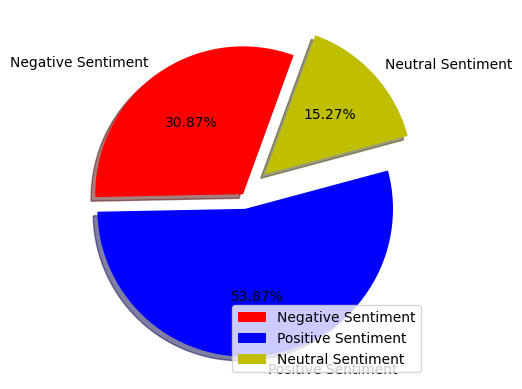

In [ ]:
sentiments = ['Negative Sentiment','Positive Sentiment', 'Neutral Sentiment']
slices = [(data['sentiment'] == 'negative').sum(), (data['sentiment'] == 'positive').sum(), (data['sentiment'] == 'neutral').sum()]
colors = ['r','b','y']
plt.pie(slices, labels = sentiments, colors=colors, startangle=70, shadow = True,
        explode = (0, 0.1,0.2), radius = 1, autopct = '%1.2f%%')
plt.legend(loc = "lower right")
plt.show()


Generates and displays a pie chart showing sentiment distribution.

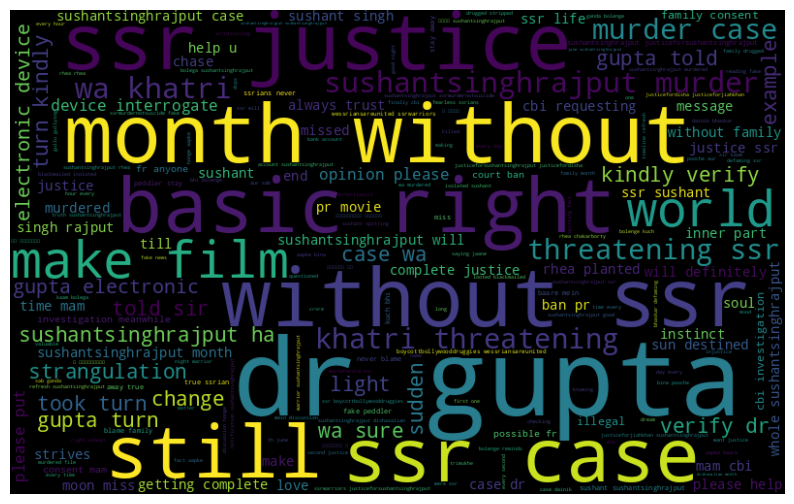

In [ ]:
all_words = ' '.join([text for text in data['processed_tweet']])
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

Generates and displays a word cloud from all processed tweets.

In [ ]:
n_class = 3
n_tweet = 500

if n_class == 2:
    df_pos = data.copy()[data.sentiment == 'positive'][:n_tweet]
    df_neg = data.copy()[data.sentiment == 'negative'][:n_tweet]
    df_neu = pd.DataFrame()
    df = pd.concat([df_pos, df_neg], ignore_index=True).reset_index(drop=True)
elif n_class == 3:
    df_pos = data.copy()[data.sentiment == 'positive'][:n_tweet]
    df_neg = data.copy()[data.sentiment == 'negative'][:n_tweet]
    df_neu = data.copy()[data.sentiment == 'neutral'][:n_tweet]
    df = pd.concat([df_pos, df_neg, df_neu], ignore_index=True).reset_index(drop=True)

Subsets data based on number of classes and tweets per class.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data['processed_tweet'], data['sentiment'], test_size=0.33, random_state=0)

df_train = pd.DataFrame()
df_test = pd.DataFrame()

df_train['processed_tweet'] = X_train
df_train['sentiment'] = y_train
df_train = df_train.reset_index(drop=True)

df_test['processed_tweet'] = X_test
df_test['sentiment'] = y_test
df_test = df_test.reset_index(drop=True)
df_test

,processed_tweet,sentiment
0,sushant you are missed a the moon miss the sun...,positive
1,sushantsinghrajput ban pr movie on sushant,negative
2,deeply saddened by this news good actor who wo...,positive
3,he in the mood of checking his notification su...,neutral
4,rhea planted in ssr life really now and cbi co...,positive
...,...,...
985,𝘼 𝙁𝙖𝙞𝙧𝙮𝙩𝙖𝙡𝙚 𝙩𝙝𝙧𝙚𝙖𝙙 𝙤𝙣 𝙎𝙪𝙨𝙝𝙖𝙣𝙩 𝙓 𝙀𝙡𝙨𝙖 sushantsi...,neutral
986,they have spent crore for sure trying to silen...,positive
987,it time we find the truth and get justice just...,positive
988,the world can change by example and not by opi...,negative


Splits data into training and testing sets and displays the test set.

In [ ]:
class TweetNBClassifier(object):

    def __init__(self, df_train):
        self.df_train = df_train
        self.df_pos = df_train.copy()[df_train.sentiment == 'positive']
        self.df_neg = df_train.copy()[df_train.sentiment == 'negative']
        self.df_neu = df_train.copy()[df_train.sentiment == 'neutral']

    def fit(self):
        Pr_pos = df_pos.shape[0]/self.df_train.shape[0]
        Pr_neg = df_neg.shape[0]/self.df_train.shape[0]
        Pr_neu = df_neu.shape[0]/self.df_train.shape[0]
        self.Prior  = (Pr_pos, Pr_neg, Pr_neu)

        self.pos_words = ' '.join(self.df_pos['processed_tweet'].tolist()).split()
        self.neg_words = ' '.join(self.df_neg['processed_tweet'].tolist()).split()
        self.neu_words = ' '.join(self.df_neu['processed_tweet'].tolist()).split()

        all_words = ' '.join(self.df_train['processed_tweet'].tolist()).split()

        self.vocab = len(Counter(all_words))

        wc_pos = len(' '.join(self.df_pos['processed_tweet'].tolist()).split())
        wc_neg = len(' '.join(self.df_neg['processed_tweet'].tolist()).split())
        wc_neu = len(' '.join(self.df_neu['processed_tweet'].tolist()).split())
        self.word_count = (wc_pos, wc_neg, wc_neu)
        return self


    def predict(self, df_test):
        class_choice = ['positive', 'negative', 'neutral']

        classification = []
        for tweet in df_test['processed_tweet']:
            text = tweet.split()

            val_pos = np.array([])
            val_neg = np.array([])
            val_neu = np.array([])
            for word in text:
                tmp_pos = np.log((self.pos_words.count(word)+1)/(self.word_count[0]+self.vocab))
                tmp_neg = np.log((self.neg_words.count(word)+1)/(self.word_count[1]+self.vocab))
                tmp_neu = np.log((self.neu_words.count(word)+1)/(self.word_count[2]+self.vocab))
                val_pos = np.append(val_pos, tmp_pos)
                val_neg = np.append(val_neg, tmp_neg)
                val_neu = np.append(val_neu, tmp_neu)

            val_pos = np.log(self.Prior[0]) + np.sum(val_pos)
            val_neg = np.log(self.Prior[1]) + np.sum(val_neg)
            val_neu = np.log(self.Prior[2]) + np.sum(val_neu)

            probability = (val_pos, val_neg, val_neu)
            classification.append(class_choice[np.argmax(probability)])
        return classification


    def score(self, feature, target):

        compare = []
        for i in range(0,len(feature)):
            if feature[i] == target[i]:
                tmp ='correct'
                compare.append(tmp)
            else:
                tmp ='incorrect'
                compare.append(tmp)
        r = Counter(compare)
        accuracy = r['correct']/(r['correct']+r['incorrect'])
        return accuracy

Defines a Naive Bayes classifier class for tweet sentiment.

In [ ]:
tnb = TweetNBClassifier(df_train)
tnb = tnb.fit()
predict = tnb.predict(df_test)
score = tnb.score(predict,df_test.sentiment.tolist())
print("Accuracy of model is: ",score)

Accuracy of model is:  0.907070707070707


Trains the Naive Bayes model, makes predictions, calculates, and prints the accuracy.